# Alanyze data using behavioral model
There are 3 models with different parameter combinations:

1. <b>The Bayesian model (Schwöbel et al. 2021):</b> \
   <b>a.</b> With 3 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, and a decision temparature $\beta$. \
   <b>b.</b> With 4 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, a decision temparature $\beta$, and a habitual tendency $h$.
2. <b>A newer MF/MB version that is better for fitting (Otto et al. 2013):</b> \
<b>Note:</b> This is not quite the original version, as the Q-values in the original work did not converge to the true expected values. Instead, I implemented a "bug-fixed" version.\
   <b>a.</b> With 4 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$$, and a repetition/perserveration parameter $p$. \
3. <b>The original model-free/model-based (MF/MB) model (Daw et al. 2005, 2011):</b> \
   <b>a.</b> With 4 parameters: a weighting parameters $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a weighting parameter $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, a dicount factor $\lambda$, and a repetition/perserveration parameter $p$.

Tell python that the code in the submodule is code that we want to import and run

In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1
Running on device cpu
torch threads 1


Other imports that we need for simulation, inference, and plotting

In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import jsonpickle as pickle
import json
import gc

Where second stage random walks from the experiment are stored

In [3]:
Rho_data_fname = os.path.join("experiment", "dawrandomwalks.mat")

Define where results should be saved

In [4]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")

In [5]:
processed_data_folder = "processed_data"

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

full_data_df = pd.read_csv(full_data_file)

In [6]:
# number of simulated agents/participants
n_agents = int(full_data_df['subject'].max()+1)
print(n_agents)

print(full_data_df.keys())

188
Index(['Unnamed: 0', 'first_stage_actions', 'second_stage_actions',
       'first_stage_rewards', 'second_stage_rewards', 'first_stage_states',
       'second_stage_states', 'miniblock_index', 'step_index',
       'common_transition', 'mask', 'repeated_actions', 'rewarded', 'subject'],
      dtype='object')


In [7]:
def convert_data_for_agent(full_data_df):

    mask = full_data_df.loc[(full_data_df["step_index"]==1)]
    mask_formatted = torch.stack([torch.from_numpy(mask.loc[mask["subject"]==i]["mask"].to_numpy()) for i in range(n_agents)])

    actions1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    actions1_formatted = torch.stack([torch.from_numpy(actions1.loc[actions1["subject"]==i]["first_stage_actions"].to_numpy()) for i in range(n_agents)])

    actions2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    actions2_formatted = torch.stack([torch.from_numpy(actions2.loc[actions2["subject"]==i]["second_stage_actions"].to_numpy()) for i in range(n_agents)])

    print("possible actions1", torch.unique(actions1_formatted[mask_formatted]))
    print("possible actions2", torch.unique(actions2_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    actions1_formatted = torch.where(mask_formatted, actions1_formatted, -1)
    actions2_formatted = torch.where(mask_formatted, actions2_formatted, -1)

    actions = torch.stack([actions1_formatted, actions2_formatted], dim=-1).permute((1,2,0))
    #print(actions.permute((0,2,1))[mask_formatted])
    # agent counts from zero:
    actions = actions-1.

    states1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    # agent counts from zero, hence -1 at the end:
    states1_formatted = torch.stack([torch.from_numpy(states1.loc[states1["subject"]==i]["first_stage_states"].to_numpy()) for i in range(n_agents)]) - 1
     
    states2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    # agent counts from zero, hence -1 at the end:
    states2_formatted = torch.stack([torch.from_numpy(states2.loc[states2["subject"]==i]["second_stage_states"].to_numpy()) for i in range(n_agents)]) - 1

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    states1_formatted = torch.where(mask_formatted, states1_formatted, -1)
    states2_formatted = torch.where(mask_formatted, states2_formatted, -1)
    # create third time step states:
    states3_formatted = states2_formatted+2 + (actions2_formatted-1)*2
    states3_formatted = torch.where(mask_formatted, states3_formatted, -1)


    print("possible states1", torch.unique(states1_formatted[mask_formatted]))
    print("possible states2", torch.unique(states2_formatted[mask_formatted]))
    print("possible states3", torch.unique(states3_formatted[mask_formatted]))

    states = torch.stack([states1_formatted, states2_formatted, states3_formatted], dim=-1).permute((1,2,0))

    # agent views r=2 as "no reward", may instead give negative reward as in Otto et al:
    rewards1_formatted = torch.zeros_like(states1_formatted) #+ 2

    rewards2_formatted = rewards1_formatted

    # create third time step rewards = second stage rewards:
    rewards3 = full_data_df.loc[(full_data_df["step_index"]==2)]
    rewards3_formatted = torch.stack([torch.from_numpy(rewards3.loc[rewards3["subject"]==i]["second_stage_rewards"].to_numpy()) for i in range(n_agents)])

    print("possible rewards1", torch.unique(rewards1_formatted[mask_formatted]))
    print("possible rewards2", torch.unique(rewards2_formatted[mask_formatted]))
    print("possible rewards3", torch.unique(rewards3_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    rewards1_formatted = torch.where(mask_formatted, rewards1_formatted, 0)
    rewards2_formatted = torch.where(mask_formatted, rewards2_formatted, 0)
    rewards3_formatted = torch.where(mask_formatted, rewards3_formatted, 0)

    rewards = torch.stack([rewards1_formatted, rewards2_formatted, rewards3_formatted], dim=-1).permute((1,2,0))


    data_dict = {"observations": states.long(), "rewards": rewards.long(), "actions": actions.long(), "valid": mask_formatted.permute((1,0))}

    return data_dict

data = convert_data_for_agent(full_data_df)

print(data)

possible actions1 tensor([1., 2.], dtype=torch.float64)
possible actions2 tensor([1., 2.], dtype=torch.float64)
possible states1 tensor([0.], dtype=torch.float64)
possible states2 tensor([1., 2.], dtype=torch.float64)
possible states3 tensor([3., 4., 5., 6.], dtype=torch.float64)
possible rewards1 tensor([0.], dtype=torch.float64)
possible rewards2 tensor([0.], dtype=torch.float64)
possible rewards3 tensor([0., 1.], dtype=torch.float64)
{'observations': tensor([[[ 0,  0,  0,  ..., -1,  0, -1],
         [ 1,  1,  2,  ..., -1,  1, -1],
         [ 3,  3,  4,  ..., -1,  5, -1]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  1,  2],
         [ 5,  3,  6,  ...,  3,  3,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  2,  2,  1],
         [ 5,  3,  6,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  2,  1],
         [ 3,  5,  4,  ...,  3,  6,  3]],

        [[ 0,  0, -1,  ..., 

In [8]:
#print(full_data["observations"][:10,:,50])

#print(full_data["actions"][:10,:,50])

#print(full_data["rewards"][:10,:,50])

#### Global experiment parameters

In [9]:
# number of simulated agents/participants
#n_agents = int(full_data_df['subject'].max()+1)
#n_agents = 15
#print(n_agents)

#start_ind = 30
#end_ind = start_ind + n_agents

#data_small = {"observations": full_data["observations"][...,start_ind:end_ind], "rewards": full_data["rewards"][...,start_ind:end_ind], "actions": full_data["actions"][...,start_ind:end_ind], "valid": full_data["valid"][...,start_ind:end_ind]}

#data = data_small

#print(data["rewards"].shape)

In [10]:
trials =  201#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
p_invalid = 1.-1./201.

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_invalid}

Define states and transition matrices

In [11]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

Load and plot reward probabilities

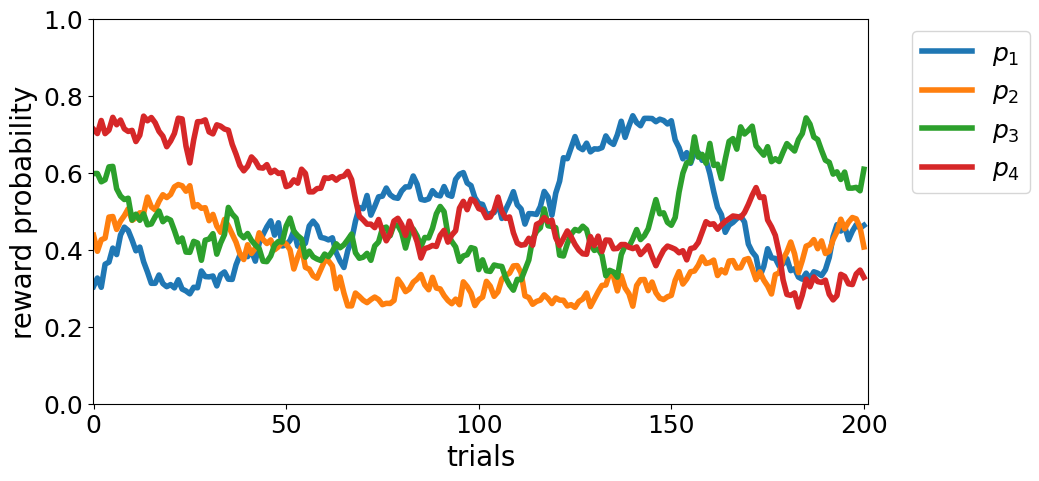

In [12]:
rew_probs = loadmat(Rho_data_fname)['dawrandomwalks']
assert trials==rew_probs.shape[-1]

Rho = torch.zeros((trials, nr, ns))

Rho[:,1,:never_reward] = 0.
Rho[:,0,:never_reward] = 1.

Rho[:,1,never_reward:never_reward+2] = torch.from_numpy(rew_probs[0,:,:]).permute((1,0))
Rho[:,0,never_reward:never_reward+2] = torch.from_numpy(1-rew_probs[0,:,:]).permute((1,0))

Rho[:,1,never_reward+2:] = torch.from_numpy(rew_probs[1,:,:]).permute((1,0))
Rho[:,0,never_reward+2:] = torch.from_numpy(1-rew_probs[1,:,:]).permute((1,0))

plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(Rho[:,1,3+i], label="$p_{}$".format(i+1), linewidth=4)
plt.ylim([0,1])
plt.yticks(torch.arange(0,1.1,0.2),fontsize=18)
plt.ylabel("reward probability", fontsize=20)
plt.xlim([-0.1, trials+0.1])
plt.xticks(range(0,trials+1,50),fontsize=18)
plt.xlabel("trials", fontsize=20)
plt.legend(fontsize=18, bbox_to_anchor=(1.04,1))
#plt.savefig(os.path.join(results_folder, "twostep_prob.svg"),dpi=300)
plt.show()

# add to parameter dict
global_experiment_parameters["Rho"] = Rho

Now we can start :) 

### 1. BCC:
### 1.a 3 parameter version

Simulation pre-setup

In [13]:
# set parameters and their names

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"sum_test_NO_context"
print(agent_type)

BCC_6pars_plan_habit_weight_cachedsum_test_NO_context


#### Inference

Inference pre-setup

In [14]:
# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

# how many inference steps
num_steps = 600

BCC_6pars_plan_habit_weight_cachedsum_test_NO_context_inference_


<b>Decide</b> for running or loading inference

In [15]:
run_inference = True

<b>Either:</b> Set up agent and inference. Run main inference loop, plot intermediate and end results

/home/sarah/src/TwoStageStrategies/Chen_et_al_data/../code/BalancingControl/perception.py:136: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)


6
analyzing 188 data sets
this is inference using <class 'inference.GeneralGroupInference'>
taking steps 1 to 100 out of total 600


Mean ELBO 49478.41: 100%|██████████| 100/100 [29:47<00:00, 17.87s/it]


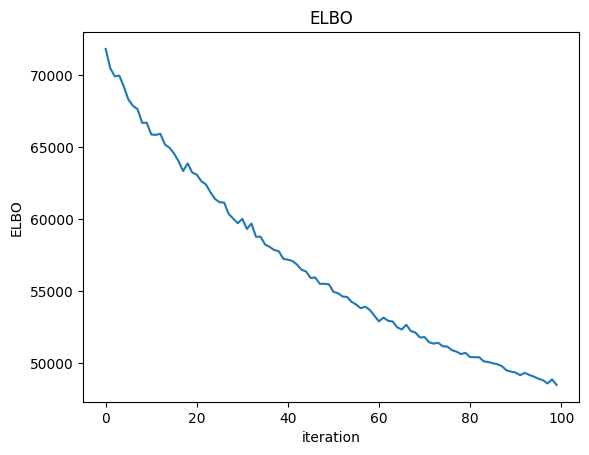

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.623796     0.151293  7.471063           2.461861       1.508639   
1         0.513540     0.299981  6.833683           1.691484       2.877511   
2         0.590730     0.430651  2.389836           2.250861       1.490115   
3         0.184825     0.234322  4.437764           3.335686       2.990073   
4         0.506053     0.504459  1.615197           3.625042       4.523324   
...            ...          ...       ...                ...            ...   
93995     0.598772     0.596344  1.126699           2.642252       3.966017   
93996     0.382574     0.405369  2.891291           2.292689       1.116755   
93997     0.677378     0.296384  8.561989           1.485534       1.140129   
93998     0.680629     0.235273  7.512183           2.751927       2.532883   
93999     0.556644     0.794259  2.262087           3.135524       4.632270   

       cached rate  subject  
0         0.613106   

<Figure size 640x480 with 0 Axes>

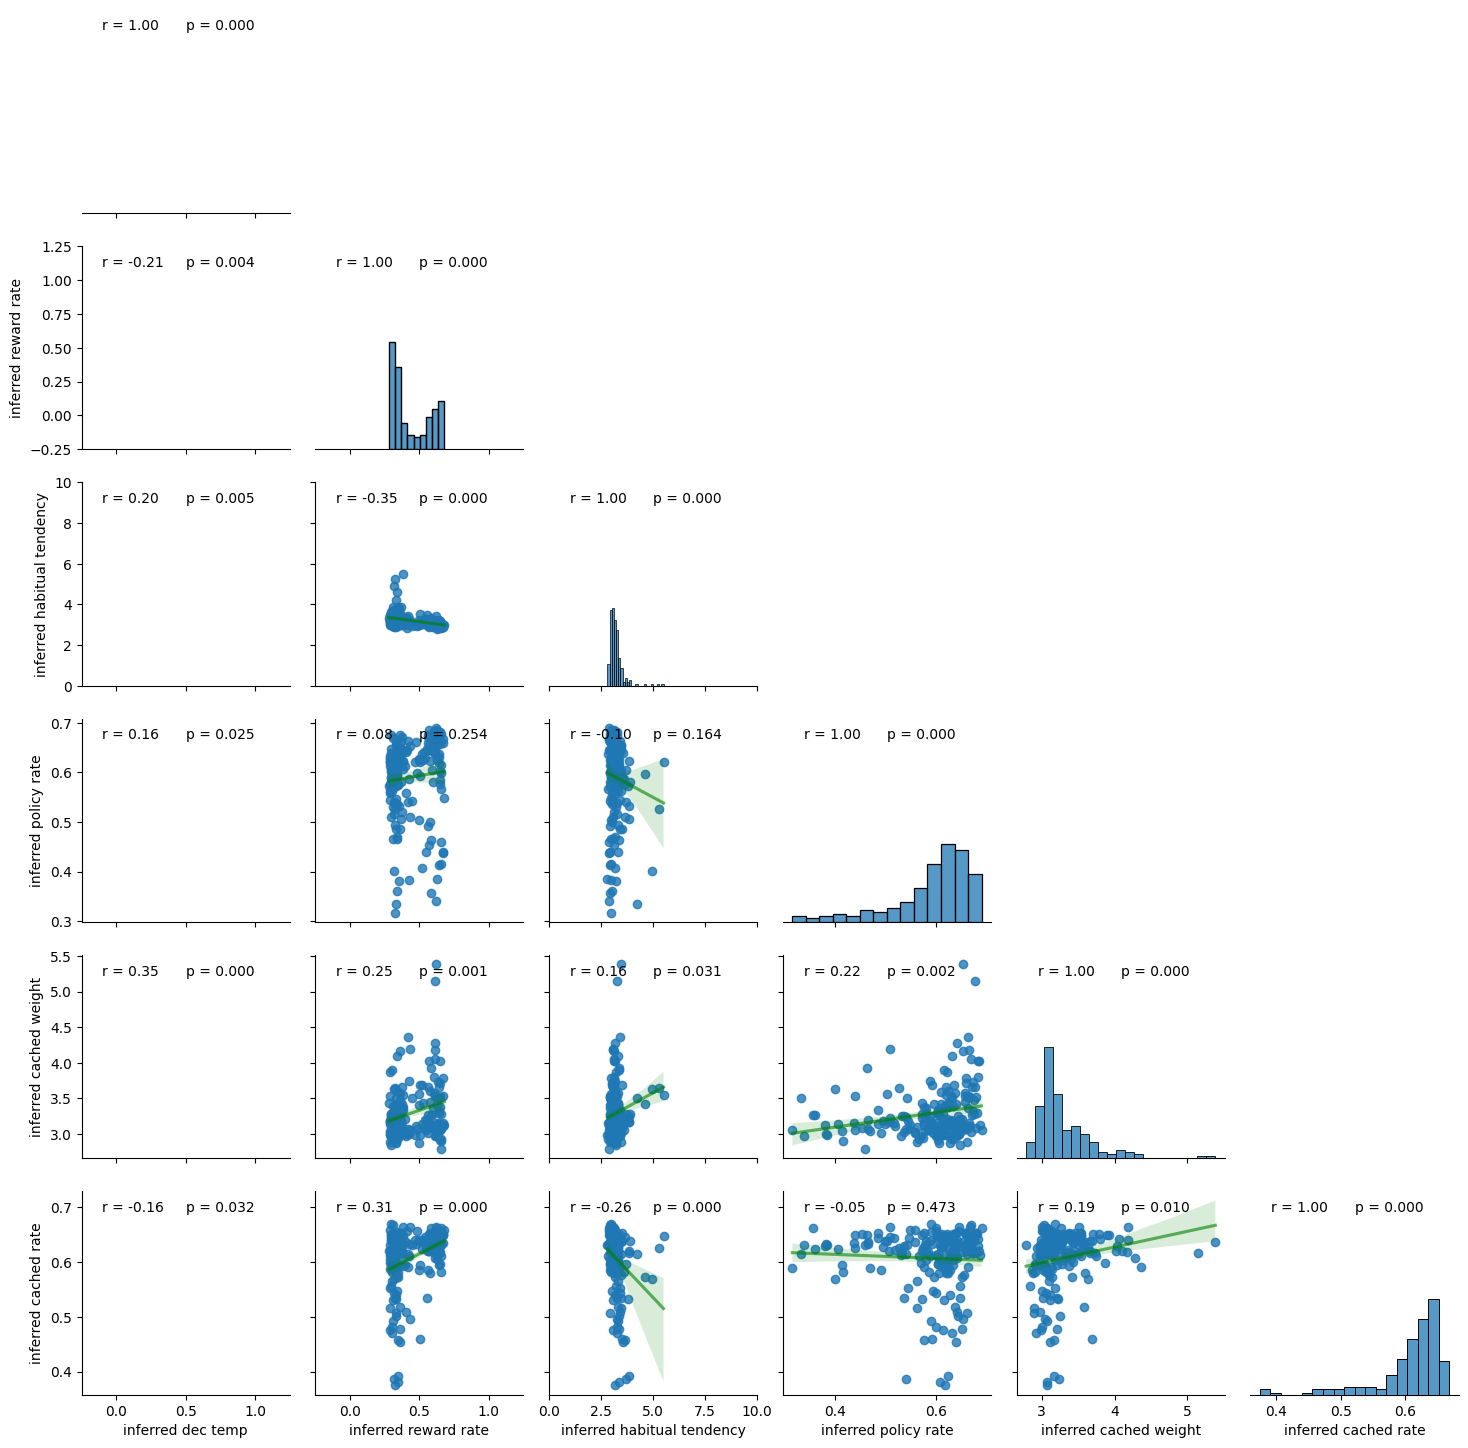

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.561104     0.232492  8.332651           3.115744       0.937219   
1         0.514584     0.319726  3.471226           2.933794       3.560273   
2         0.771687     0.602793  4.383289           3.213073       1.083312   
3         0.150697     0.506493  5.575667           2.445730       2.559939   
4         0.767014     0.641184  4.386741           3.354988       2.457385   
...            ...          ...       ...                ...            ...   
93995     0.663596     0.431482  3.872936           2.389238       2.274502   
93996     0.497170     0.346119  4.140231           3.863680       4.389708   
93997     0.520647     0.324463  7.288812           2.956901       3.063300   
93998     0.547390     0.584152  3.254169           1.993291       3.658265   
93999     0.615844     0.700426  1.912608           2.753839       3.957848   

       cached rate  subject  
0         0.532025   

Mean ELBO 43955.27: 100%|██████████| 100/100 [31:31<00:00, 18.92s/it]


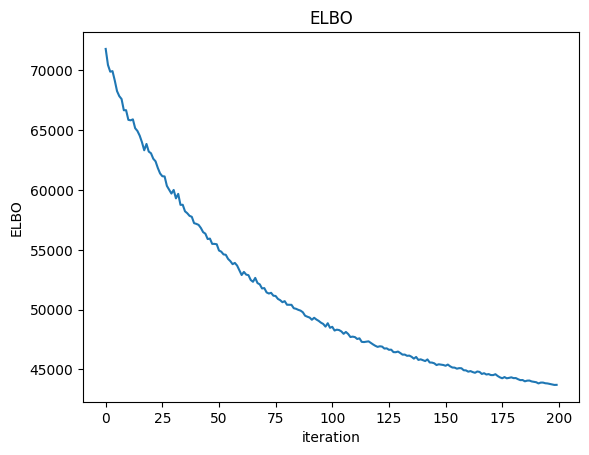

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.866579     0.121715  6.579610           1.587696       1.065206   
1         0.591517     0.182444  6.682289           2.529881       1.078472   
2         0.690324     0.868450  1.659925           1.995249       1.945530   
3         0.399229     0.537694  0.851039           1.853881       1.818634   
4         0.626178     0.668471  2.206501           1.819880       0.939346   
...            ...          ...       ...                ...            ...   
93995     0.826250     0.789777  2.531630           2.245981       2.729900   
93996     0.616495     0.228759  1.839260           2.342706       2.117133   
93997     0.336453     0.309654  7.859751           3.469913       4.273830   
93998     0.356142     0.222950  8.113521           1.328739       0.955835   
93999     0.493355     0.690994  3.206370           1.993482       2.637668   

       cached rate  subject  
0         0.543029   

<Figure size 640x480 with 0 Axes>

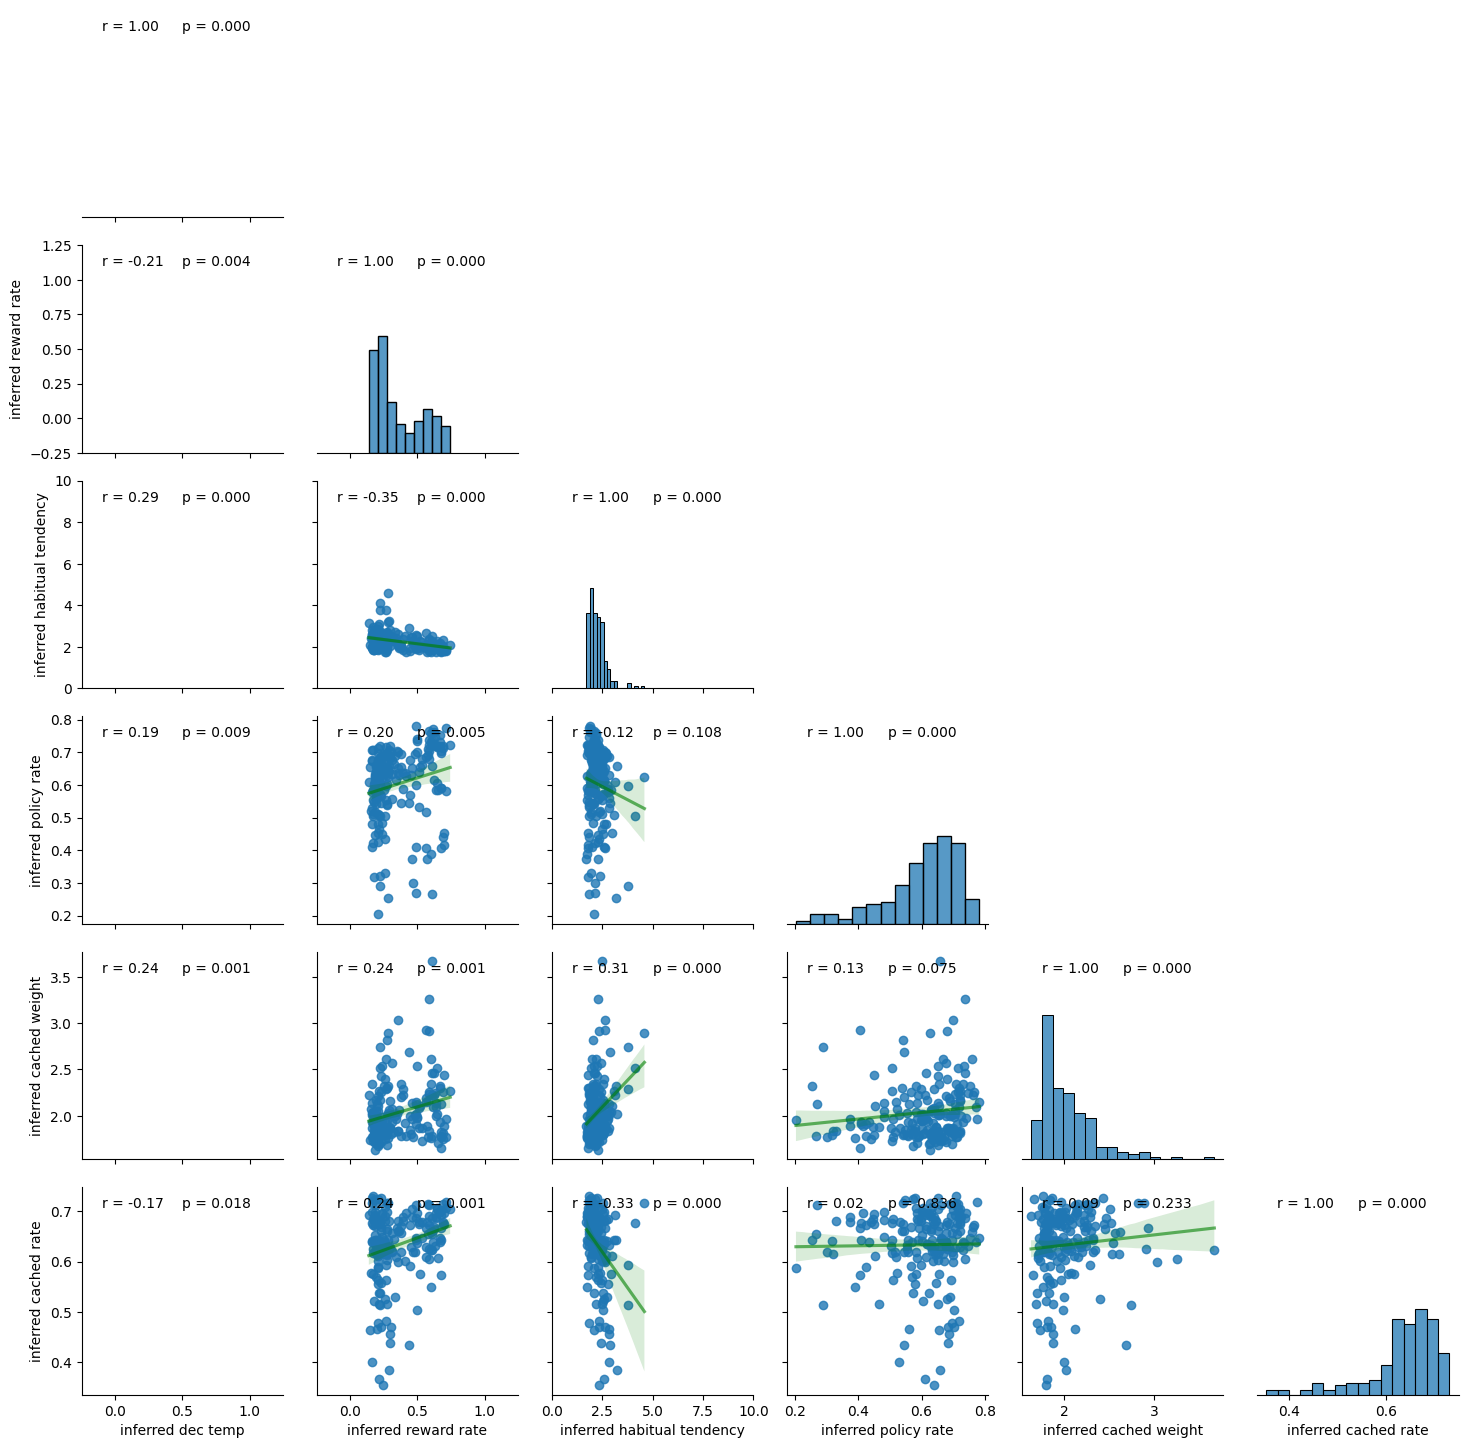

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.766077     0.172783  5.352910           2.052409       2.030847   
1         0.454666     0.207466  6.692873           2.300642       1.796772   
2         0.785805     0.576770  1.887667           2.905477       3.048603   
3         0.453023     0.007502  3.065998           3.053144       2.973699   
4         0.702439     0.486162  2.931275           2.492176       1.736015   
...            ...          ...       ...                ...            ...   
93995     0.738807     0.624230  1.196587           1.732859       3.206827   
93996     0.628573     0.544776  3.658046           2.393869       0.932660   
93997     0.649590     0.285832  7.908219           2.229866       2.320566   
93998     0.596598     0.180621  8.011006           2.202897       3.145966   
93999     0.751546     0.443299  0.920096           2.710439       3.441037   

       cached rate  subject  
0         0.413007   

Mean ELBO 42462.39: 100%|██████████| 100/100 [30:49<00:00, 18.50s/it]


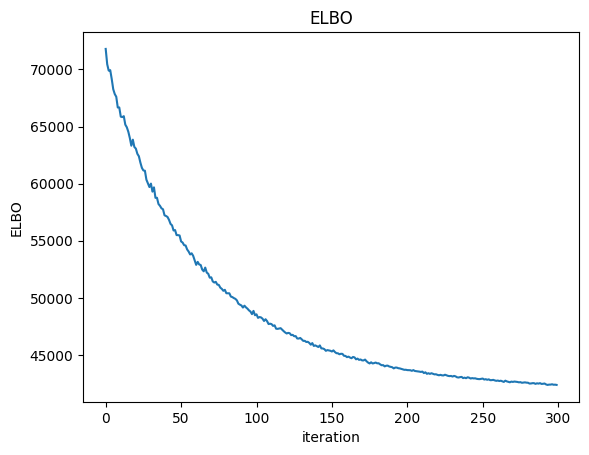

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.818580     0.142392  4.716509           1.600899       0.768975   
1         0.506212     0.205694  6.290882           2.273178       2.002788   
2         0.703439     0.521891  1.668041           1.439010       1.832669   
3         0.295457     0.310171  1.114718           2.705121       1.678619   
4         0.794958     0.264945  2.374115           2.738877       1.997452   
...            ...          ...       ...                ...            ...   
93995     0.623509     0.820813  1.486487           1.411304       2.725387   
93996     0.453868     0.398317  2.982296           2.338394       1.323026   
93997     0.665900     0.313957  7.639791           1.597996       1.306988   
93998     0.497810     0.268937  8.060053           1.833002       1.407433   
93999     0.709846     0.748401  2.088152           1.460950       1.126733   

       cached rate  subject  
0         0.665041   

<Figure size 640x480 with 0 Axes>

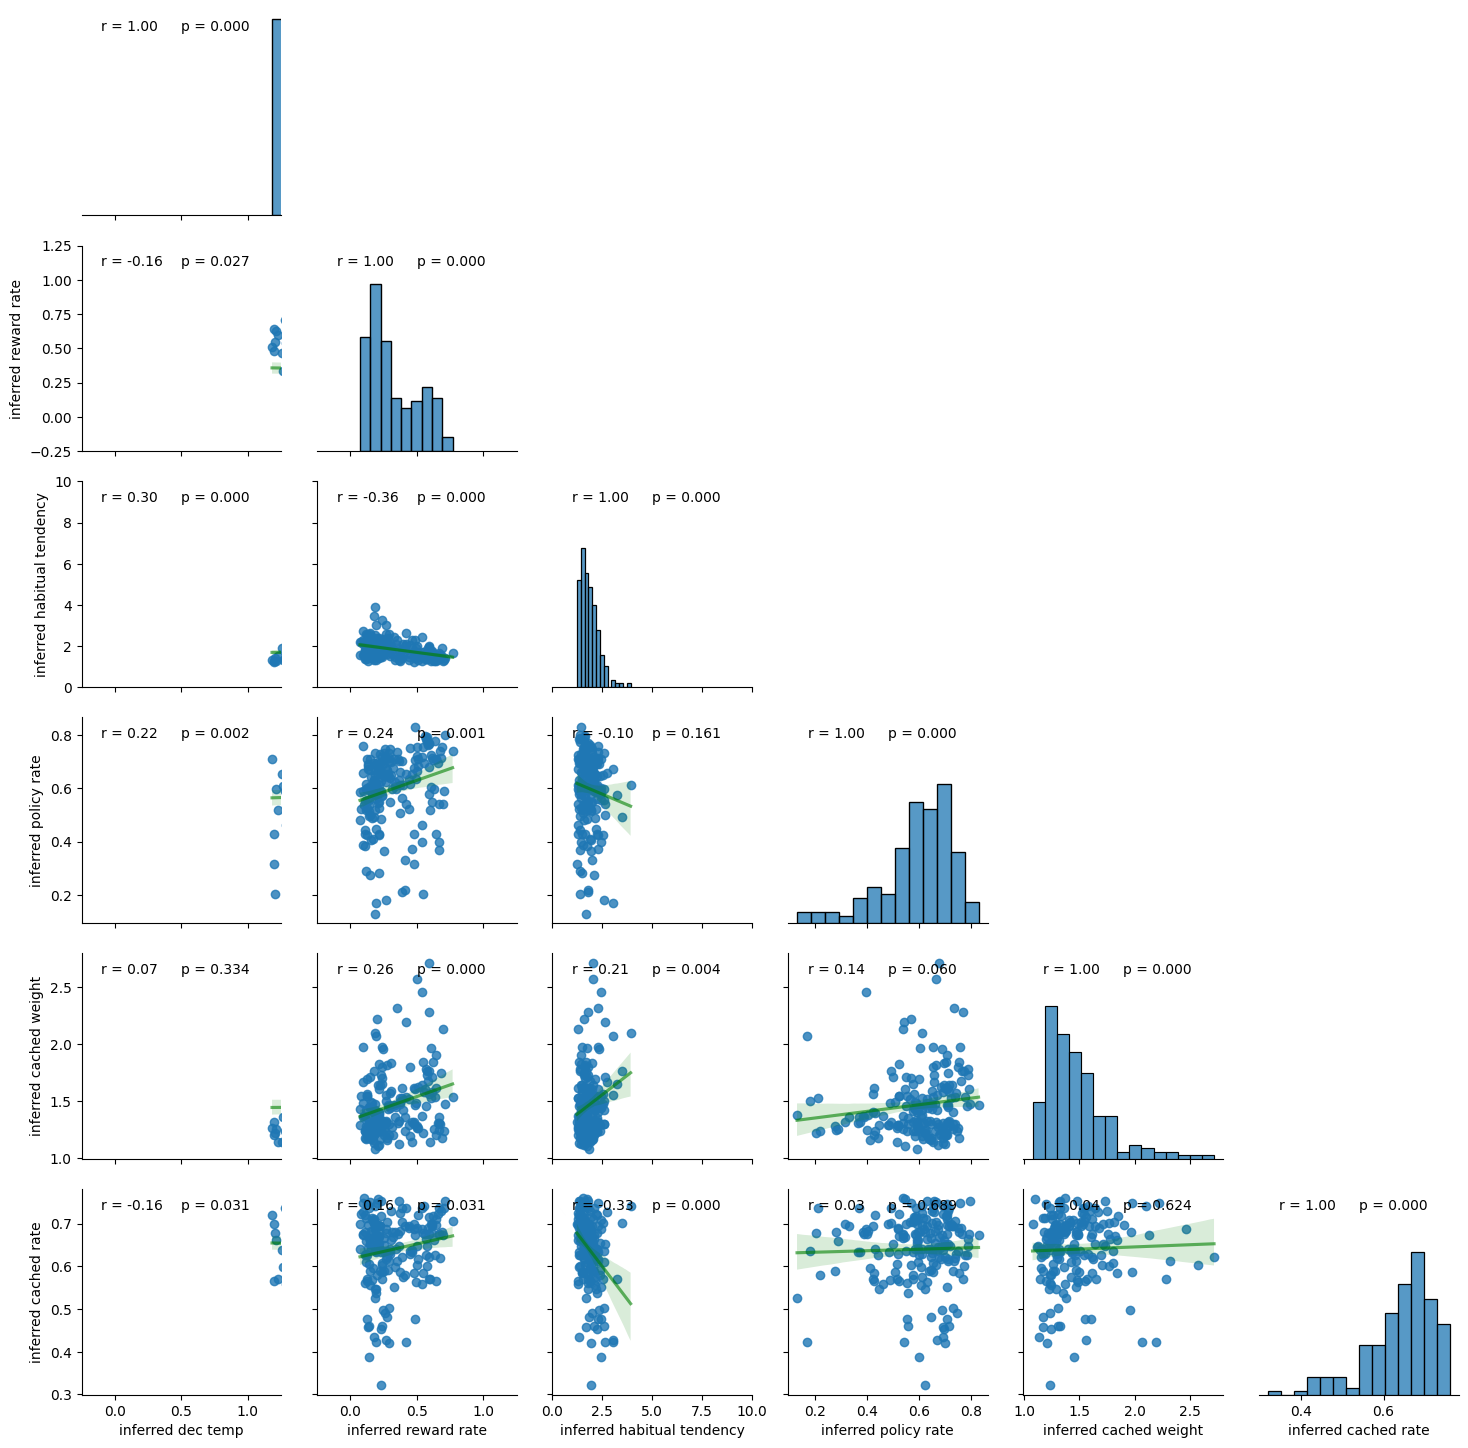

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.712084     0.170565  5.833046           2.117663       1.229280   
1         0.577400     0.216435  6.818571           2.425747       1.359052   
2         0.503858     0.334415  2.098553           1.541238       1.143717   
3         0.287710     0.051760  1.736356           1.912857       0.953243   
4         0.462770     0.296806  1.897255           2.457200       2.037082   
...            ...          ...       ...                ...            ...   
93995     0.654296     0.537208  2.417152           1.123369       0.728902   
93996     0.869184     0.260074  2.781428           2.451301       1.789526   
93997     0.528465     0.251066  8.468317           1.712610       2.155919   
93998     0.758570     0.203369  6.296590           1.812274       1.407001   
93999     0.699429     0.449551  1.287801           1.295380       1.461090   

       cached rate  subject  
0         0.615766   

Mean ELBO 41929.59: 100%|██████████| 100/100 [31:41<00:00, 19.01s/it]


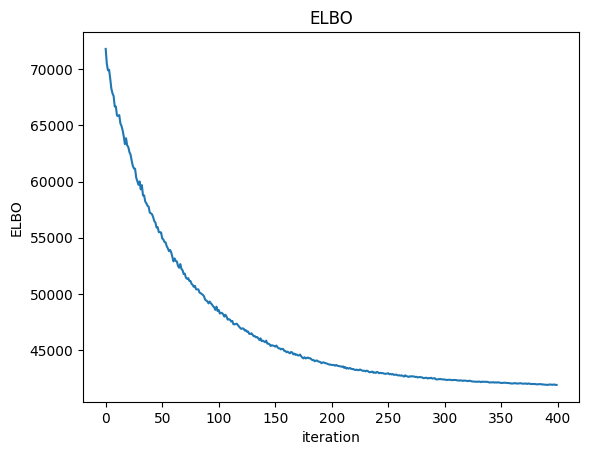

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.640771     0.149258  5.761662           1.935196       1.734673   
1         0.724325     0.145780  6.312888           1.949415       0.636676   
2         0.757180     0.379249  1.503994           2.138628       1.371953   
3         0.220435     0.062758  1.663575           2.422394       1.515835   
4         0.632087     0.388314  1.929170           2.085087       1.297758   
...            ...          ...       ...                ...            ...   
93995     0.778828     0.278976  0.758471           0.789183       1.405113   
93996     0.761952     0.306478  2.854971           2.870386       1.175556   
93997     0.433752     0.312893  7.415135           1.274743       0.745447   
93998     0.616469     0.201381  7.937968           1.219975       1.248394   
93999     0.774893     0.718887  2.787835           0.776951       0.616812   

       cached rate  subject  
0         0.633122   

<Figure size 640x480 with 0 Axes>

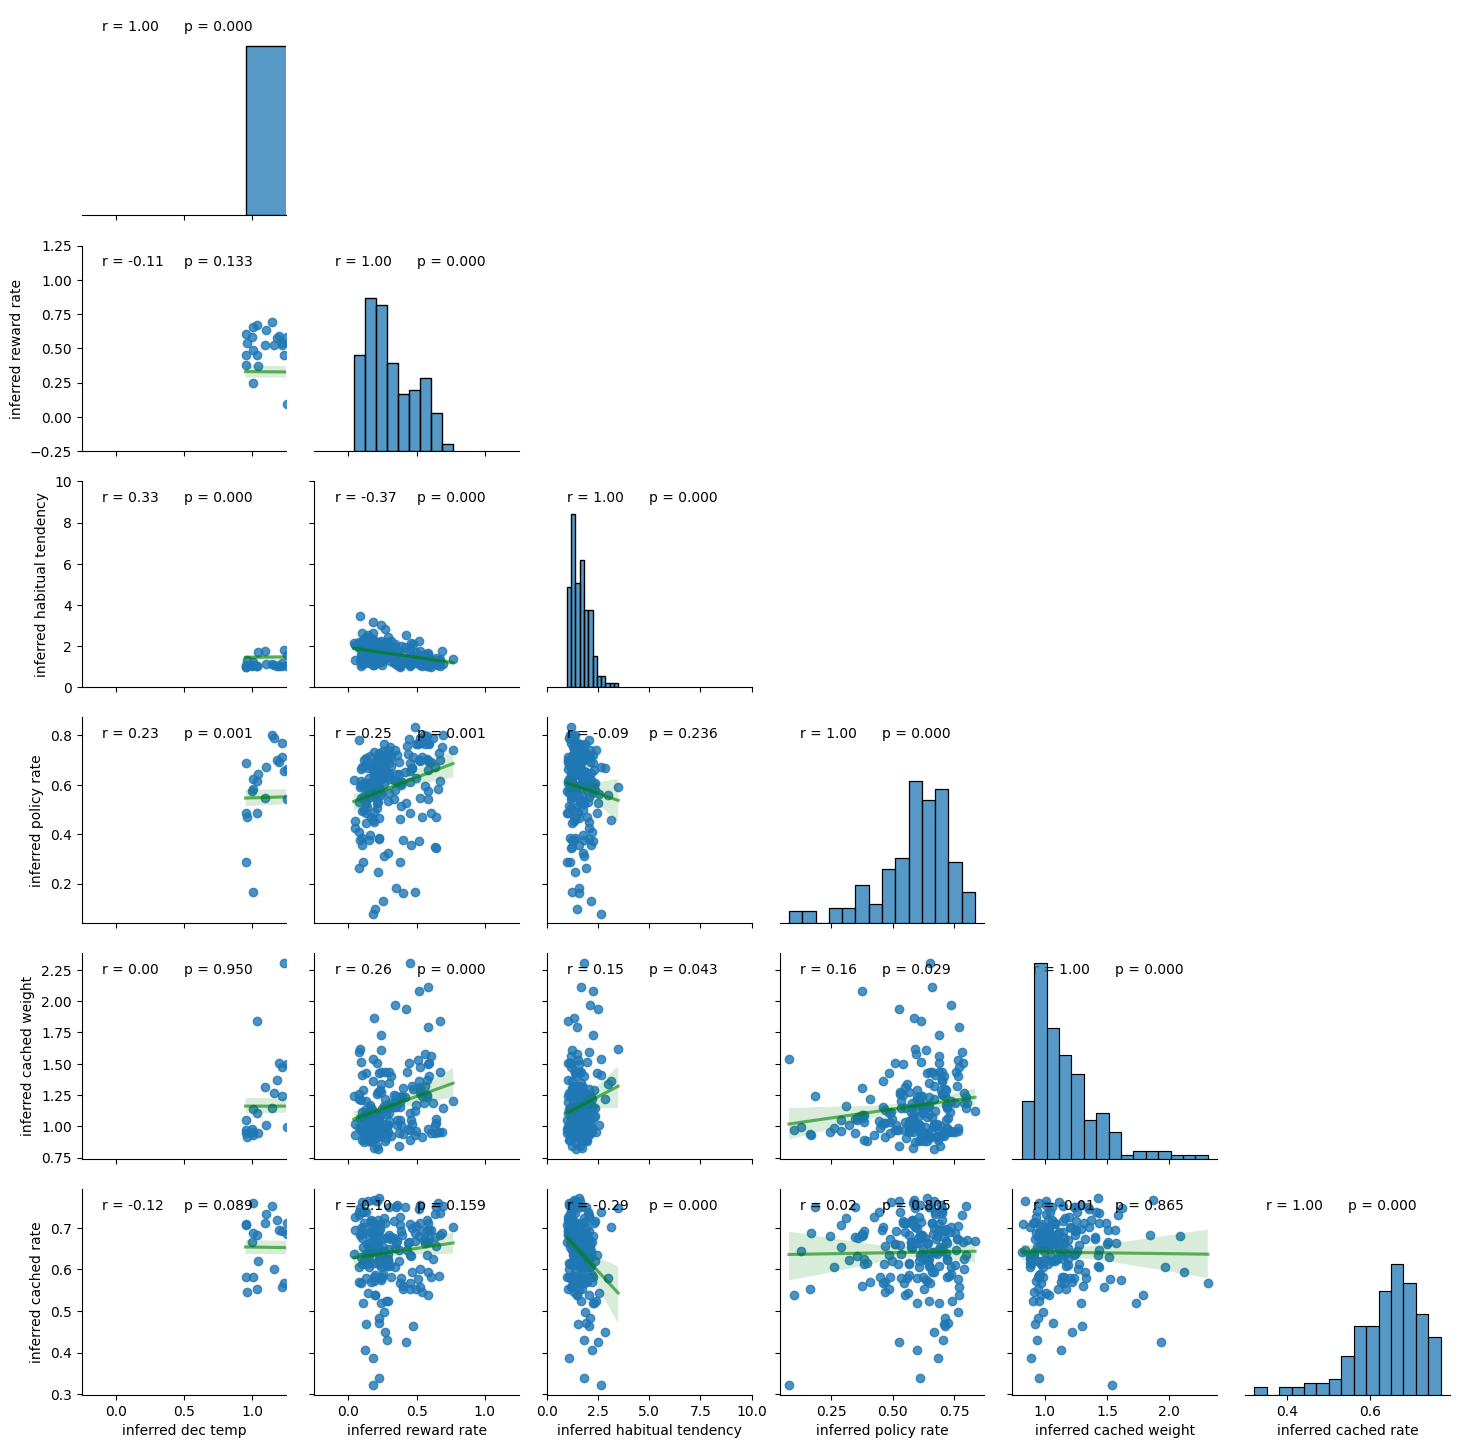

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.799407     0.116154  7.430130           1.939085       1.398521   
1         0.572966     0.195152  7.475487           2.607978       1.384941   
2         0.406118     0.113495  1.296052           1.915264       2.053593   
3         0.447145     0.004417  1.837406           1.888940       0.930827   
4         0.500800     0.396917  2.070379           2.012790       1.258871   
...            ...          ...       ...                ...            ...   
93995     0.616246     0.758227  0.937892           0.970808       1.603489   
93996     0.851507     0.291393  2.086791           2.543153       1.383370   
93997     0.499813     0.253501  8.086600           1.637724       0.715135   
93998     0.440478     0.248769  7.498106           1.446988       1.191672   
93999     0.628081     0.542459  2.718371           0.910729       0.876382   

       cached rate  subject  
0         0.367111   

Mean ELBO 41693.70: 100%|██████████| 100/100 [29:25<00:00, 17.65s/it]


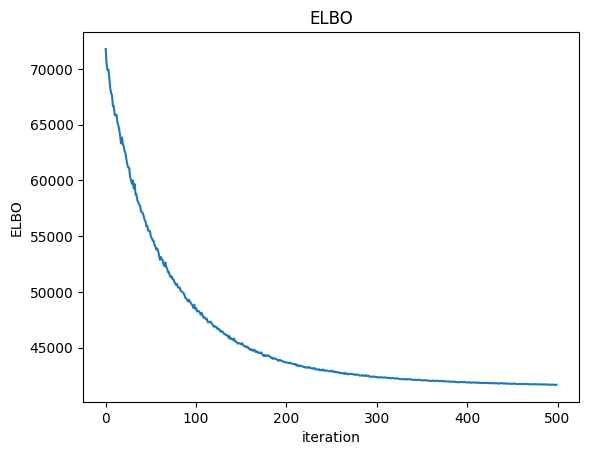

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.598588     0.119060  7.334059           1.583263       0.655773   
1         0.522141     0.194291  7.277871           1.784579       0.641597   
2         0.506388     0.194202  0.873852           1.702550       1.405075   
3         0.231561     0.019271  1.941509           2.162710       0.838479   
4         0.775828     0.331488  2.268783           2.108829       1.401925   
...            ...          ...       ...                ...            ...   
93995     0.788104     0.493660  0.580910           0.838320       0.846103   
93996     0.729771     0.251827  3.127837           2.269089       0.706483   
93997     0.642501     0.294193  8.753372           1.655603       0.745265   
93998     0.511514     0.225348  7.023340           1.489952       1.845355   
93999     0.655233     0.643217  1.061436           1.128747       1.132209   

       cached rate  subject  
0         0.448816   

<Figure size 640x480 with 0 Axes>

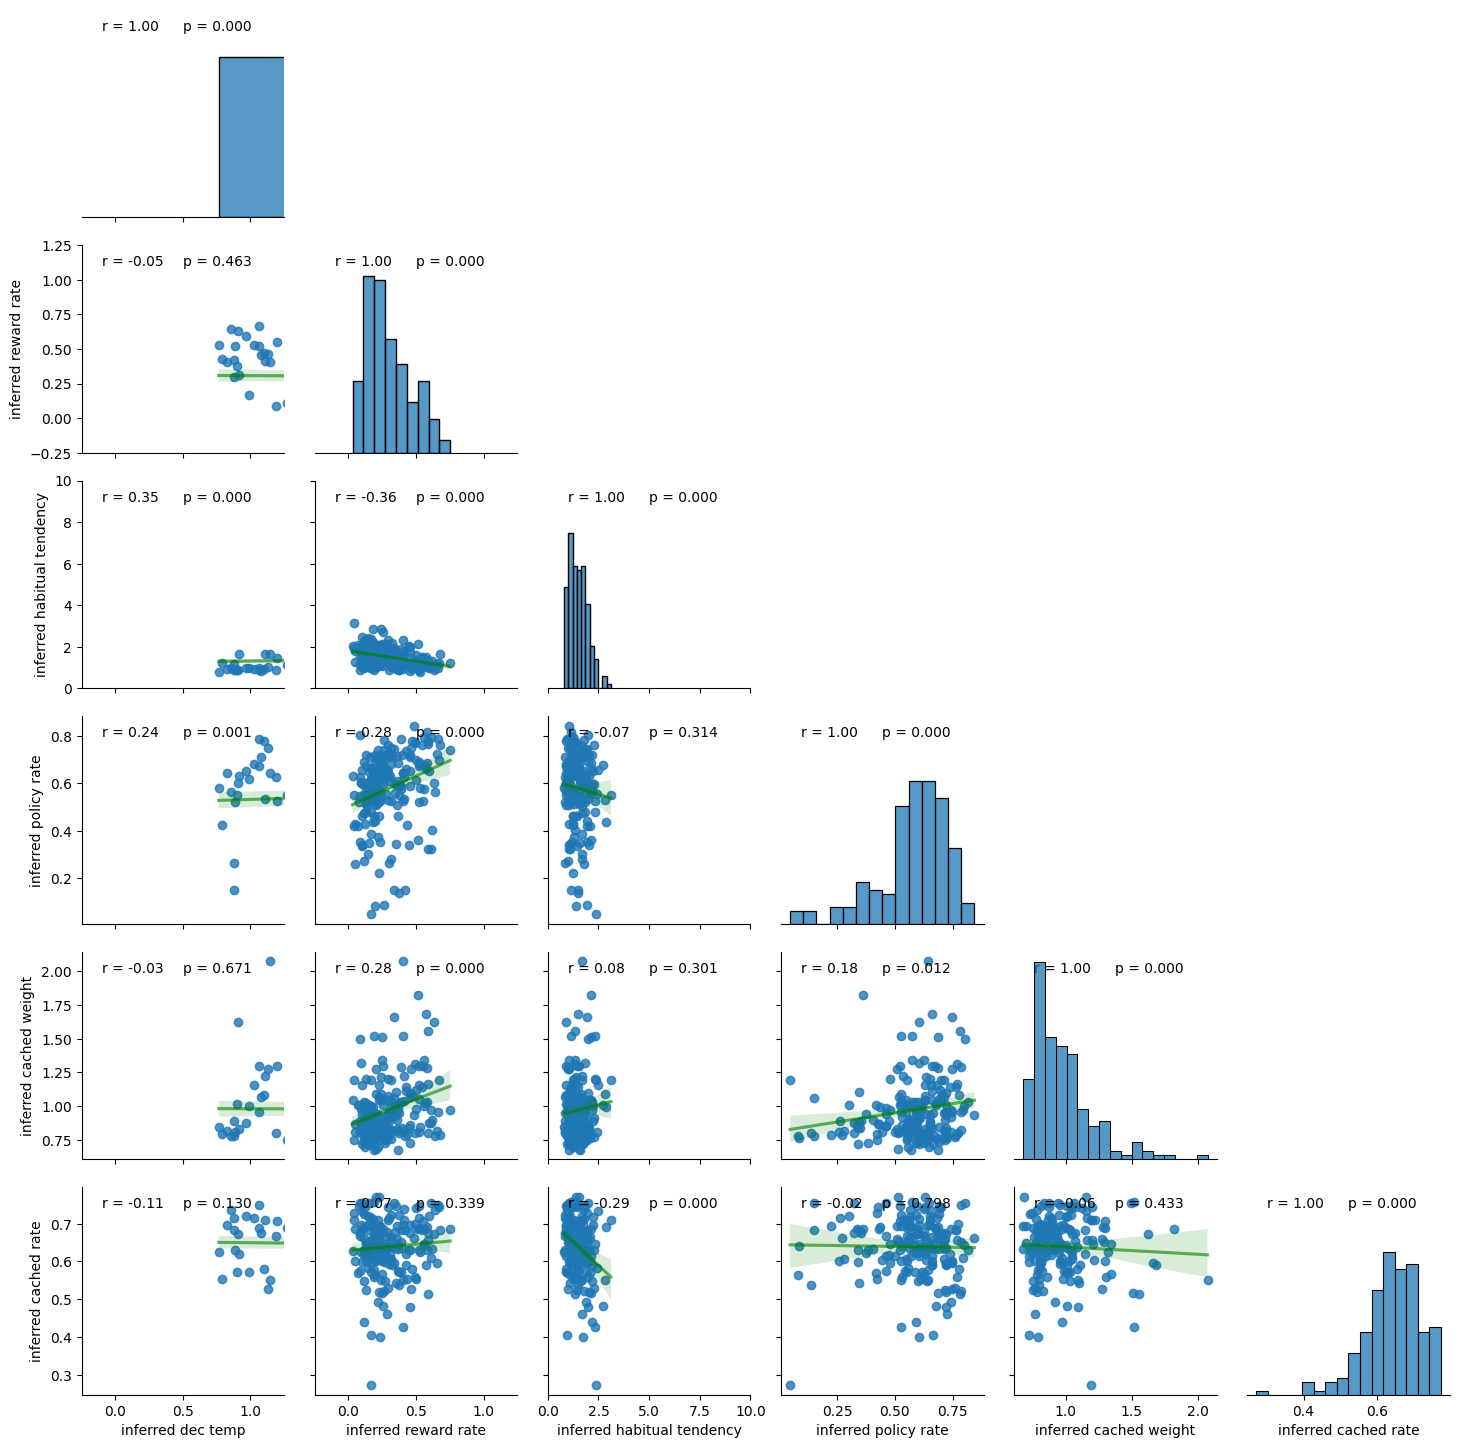

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.798768     0.146050  6.936512           1.605873       1.224066   
1         0.713780     0.218007  5.941529           2.659719       1.223603   
2         0.440910     0.227565  1.143142           1.240448       1.498047   
3         0.297533     0.029974  1.511026           1.973747       1.075040   
4         0.623552     0.460206  2.210068           2.195118       1.265100   
...            ...          ...       ...                ...            ...   
93995     0.795874     0.670417  1.748590           0.691462       1.248780   
93996     0.796949     0.358910  3.644296           2.624844       0.814528   
93997     0.796348     0.227430  8.624127           1.326341       0.848207   
93998     0.596930     0.248186  8.367142           1.266491       1.138210   
93999     0.691658     0.879844  2.202450           0.995616       0.960272   

       cached rate  subject  
0         0.891784   

Mean ELBO 41565.22: 100%|██████████| 100/100 [25:51<00:00, 15.52s/it]


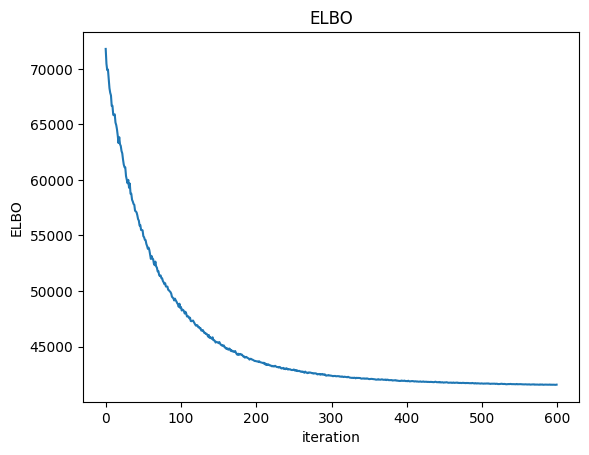

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.607876     0.146596  5.928365           1.252502       0.972606   
1         0.675065     0.194714  6.359648           2.509265       1.029323   
2         0.534623     0.286670  1.704925           1.631652       1.526371   
3         0.231180     0.068847  3.738812           2.247422       0.925765   
4         0.395228     0.525896  2.357049           1.988588       1.345510   
...            ...          ...       ...                ...            ...   
93995     0.625476     0.318723  0.892705           0.607347       1.220411   
93996     0.693084     0.244541  3.230445           1.990644       1.040584   
93997     0.734845     0.289255  7.962793           1.532062       0.793179   
93998     0.591532     0.237808  8.220407           1.172125       1.423396   
93999     0.862945     0.772585  2.898910           1.455255       0.899044   

       cached rate  subject  
0         0.499128   

<Figure size 640x480 with 0 Axes>

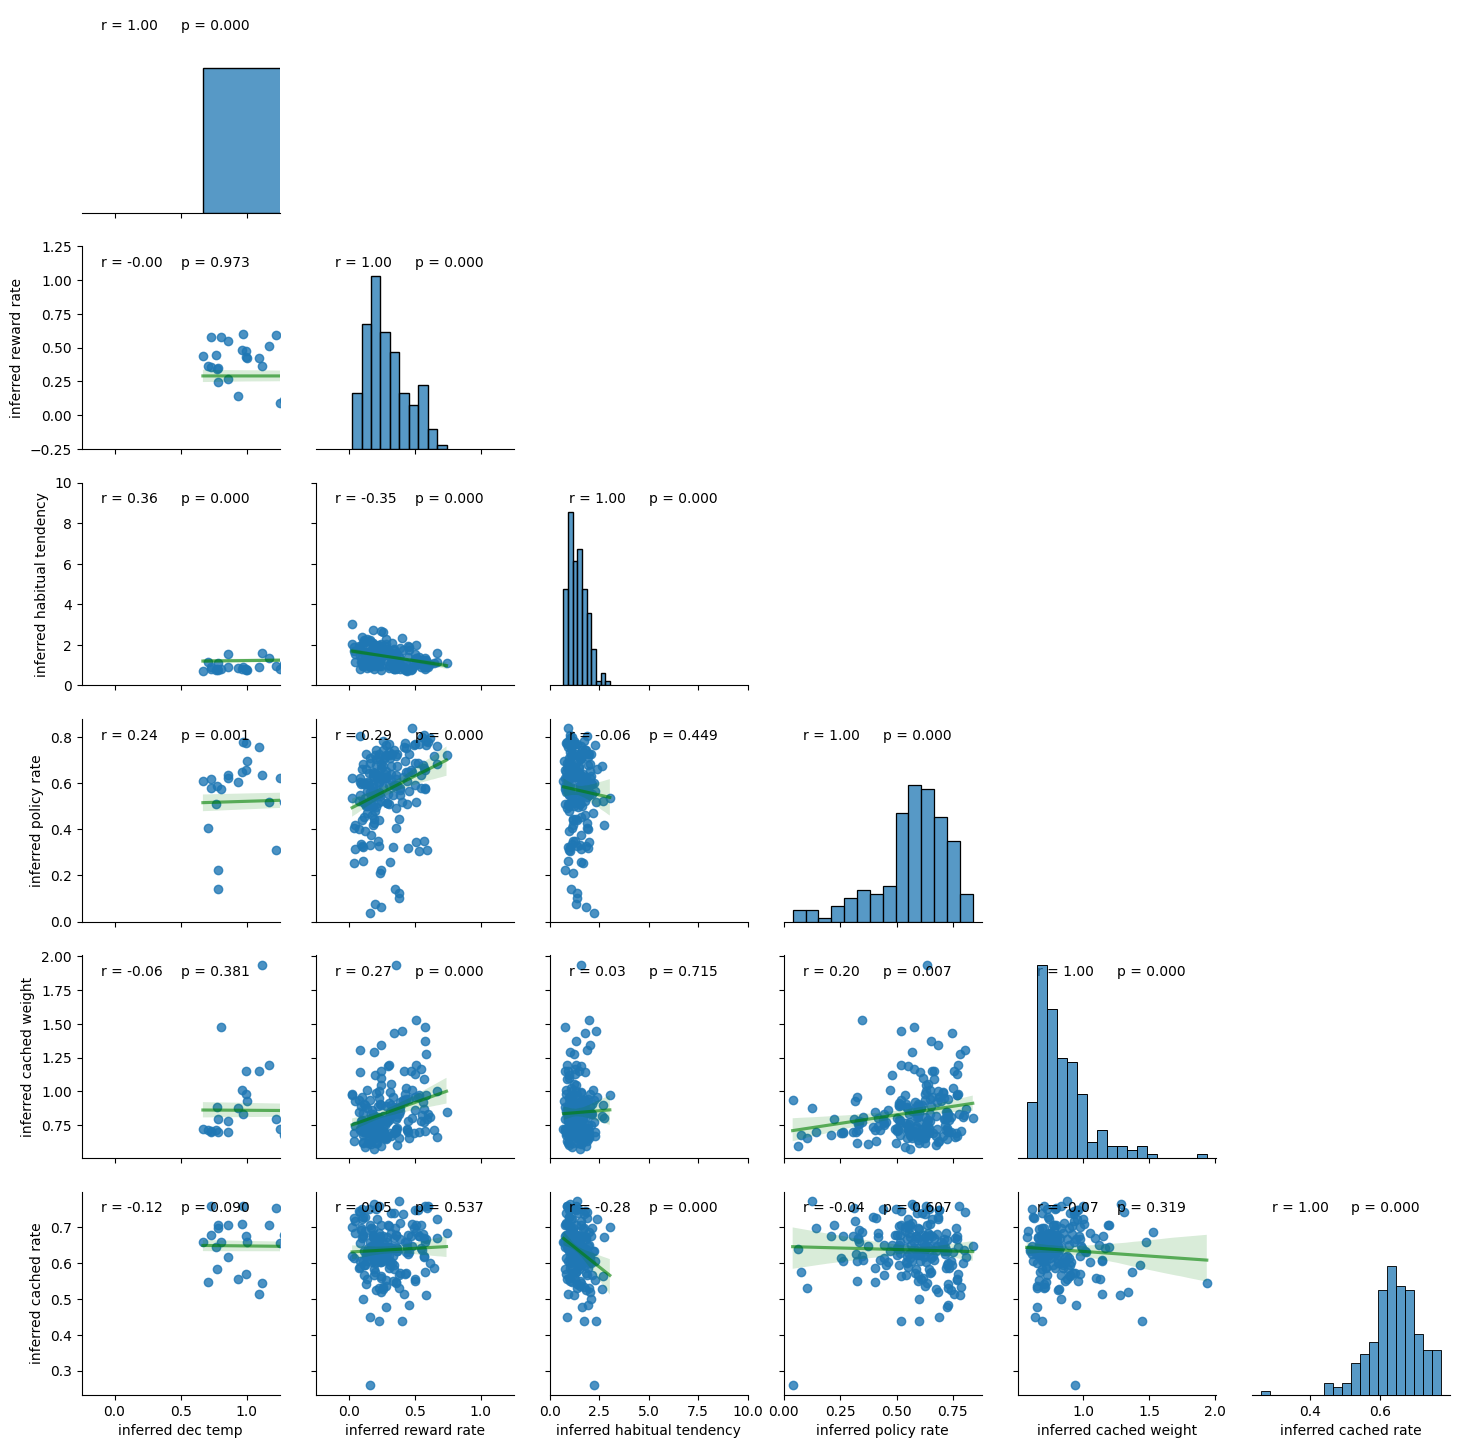

       policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0         0.594970     0.151743  6.902428           1.636539       0.923147   
1         0.677833     0.210087  6.441333           3.091296       1.866884   
2         0.856462     0.185241  1.900131           1.737770       0.765815   
3         0.166166     0.056807  3.282862           1.568747       0.710711   
4         0.612902     0.436363  3.882192           1.878830       0.711491   
...            ...          ...       ...                ...            ...   
93995     0.777208     0.215020  0.930871           0.595741       1.005936   
93996     0.758614     0.230891  4.119687           1.732503       0.716346   
93997     0.722879     0.250825  7.941210           1.195404       0.522756   
93998     0.573933     0.236816  7.253745           0.954338       1.048135   
93999     0.640437     0.443351  2.645025           0.883829       0.783749   

       cached rate  subject  
0         0.635260   

In [16]:
if run_inference:

    # remove old inference?
    remove_old = False

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=remove_old, 
                                                    use_h=use_h)
                                                    
    print('analyzing '+str(n_agents)+' data sets')

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    num_particles = 15


    print("this is inference using", type(inferrer))
    
    size_chunk = 100
    total_num_iter_so_far = 0

    for i in range(total_num_iter_so_far, num_steps, size_chunk):
        print('taking steps '+str(i+1)+' to '+str(i+size_chunk)+' out of total '+str(num_steps))

        fname_str = fname_base + str(total_num_iter_so_far+size_chunk)+'_'+str(n_agents)+'agents'

        iu.infer(inferrer, size_chunk, fname_str, num_particles, base_dir)
        total_num_iter_so_far += size_chunk

        inferrer.save_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

        inferrer.save_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

        param_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

        plt.figure()
        vars_of_interest = ["inferred "+name for name in param_names]
        f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,# hue="subject",
                            plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                            grid_kws={"layout_pad": 1.5},
                            x_vars=vars_of_interest, y_vars=vars_of_interest)
        f.map(tu.annot_corrfunc)
        for p, p_range in enumerate(param_ranges):
            f.axes[n_pars-1,p].set_xlim(p_range)
            f.axes[p,0].set_ylim(p_range)
        #f.axes[2,0].set_ylim(param_ranges[0])
        #f.axes[1,0].set_ylim(param_ranges[1])
        #f.axes[2,0].set_ylim(param_ranges[2])
        plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
        plt.show()

        # sample from posterior only at last time step and save results. Could be done at every step, if earlier posteriors are of interest, one can load the inferrer save and sample from that.
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

<b>Or:</b> Set up agent and inference. Load past inference, decide whether to resample posterior or used stored samples

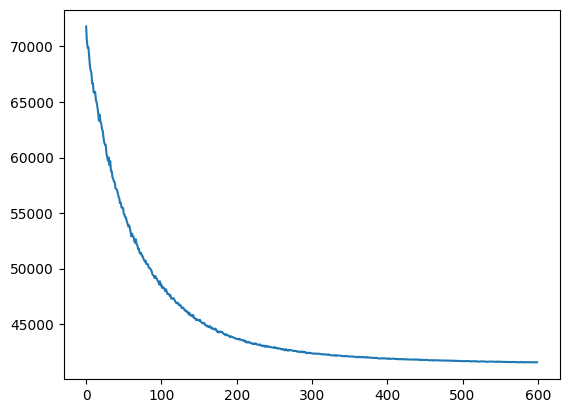

last ELBO: tensor(41568.9023)


In [17]:
if not run_inference:

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)
                                                    
    print('analyzing '+str(n_agents)+' data sets')

    resample = True

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

plt.figure()
plt.plot(inferrer.loss)
plt.show()

print("last ELBO:", inferrer.loss[-1])

<Figure size 640x480 with 0 Axes>

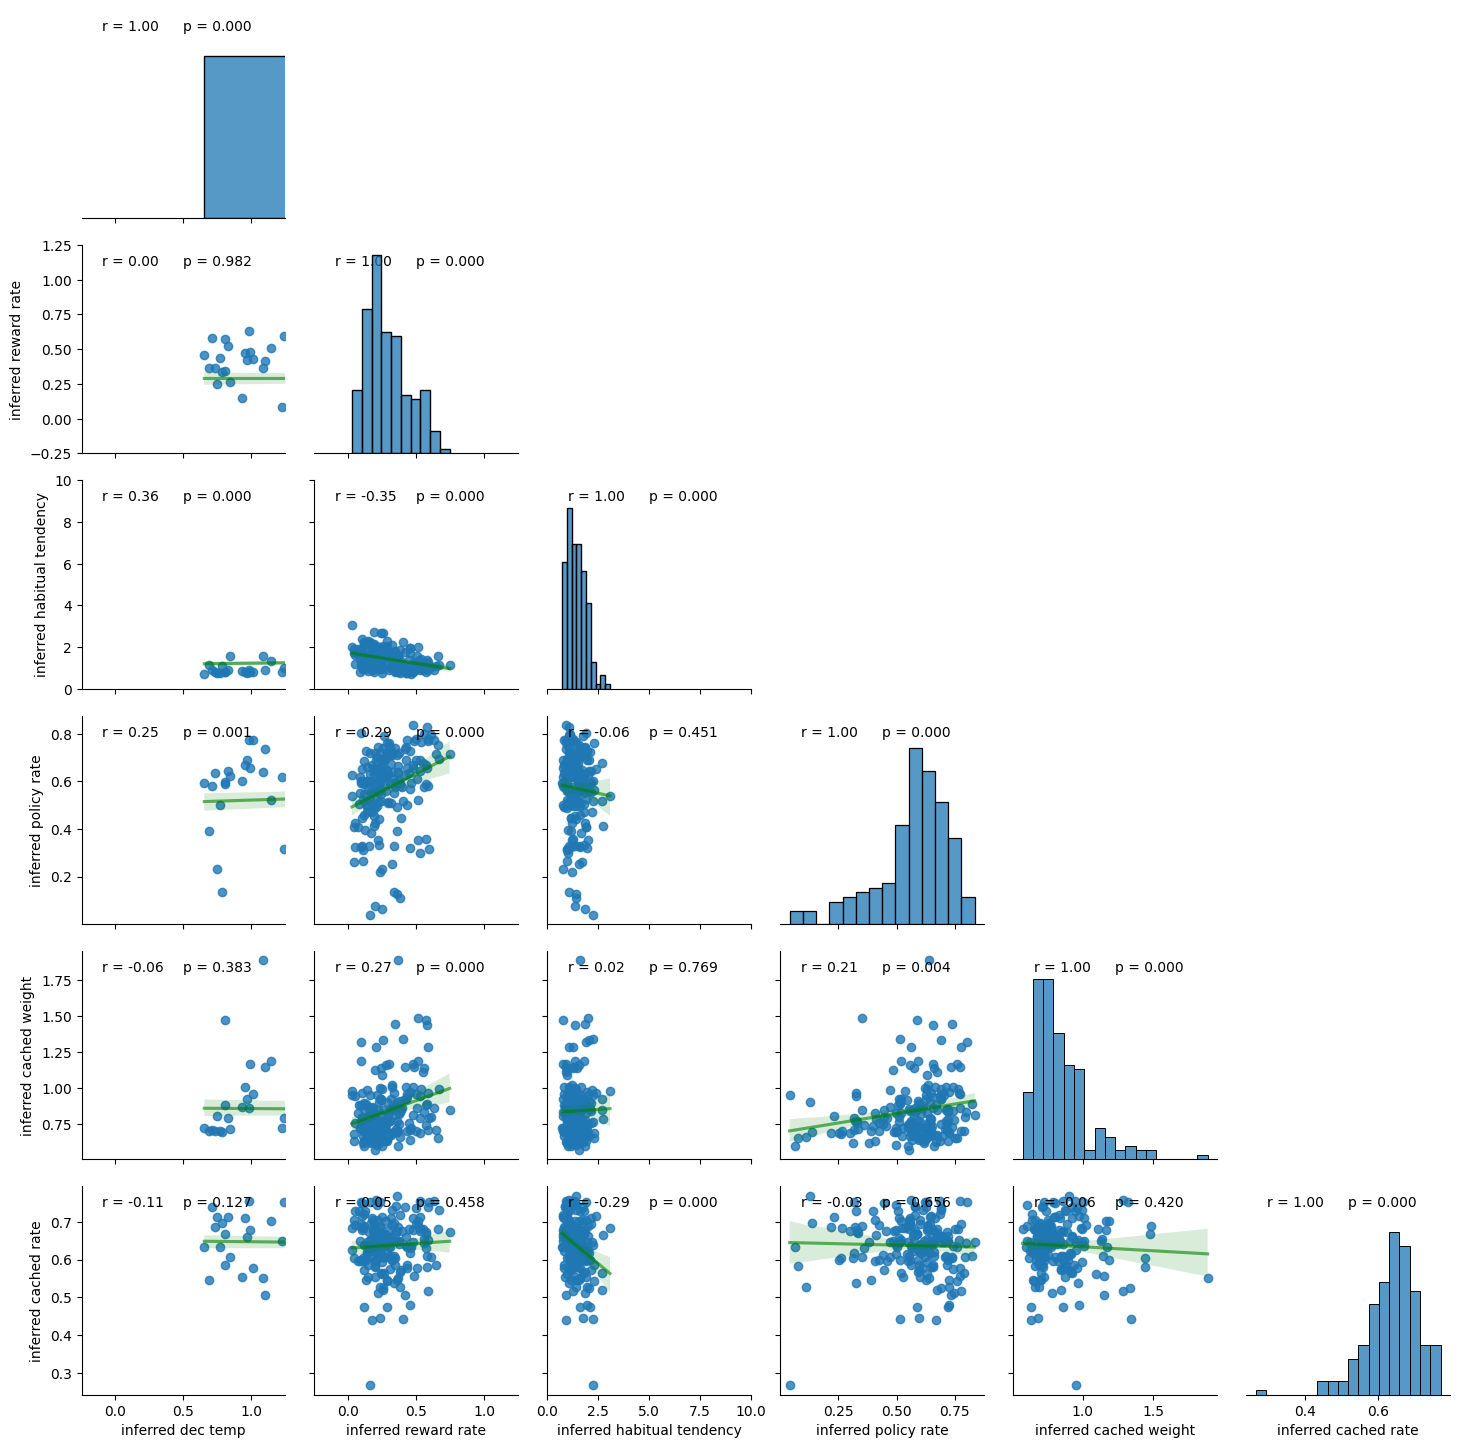

This is inference for the twostage task using the Bayesian prior-based contextual control model(BCC_6pars_plan_habit_weight_cachedsum_test_NO_context) with 188 agents.


In [18]:
plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    grid_kws={"layout_pad": 1.5},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()
        
print("This is inference for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")

['inferred dec temp', 'inferred reward rate', 'inferred habitual tendency', 'inferred policy rate', 'inferred cached weight', 'inferred cached rate']


<Figure size 640x480 with 0 Axes>

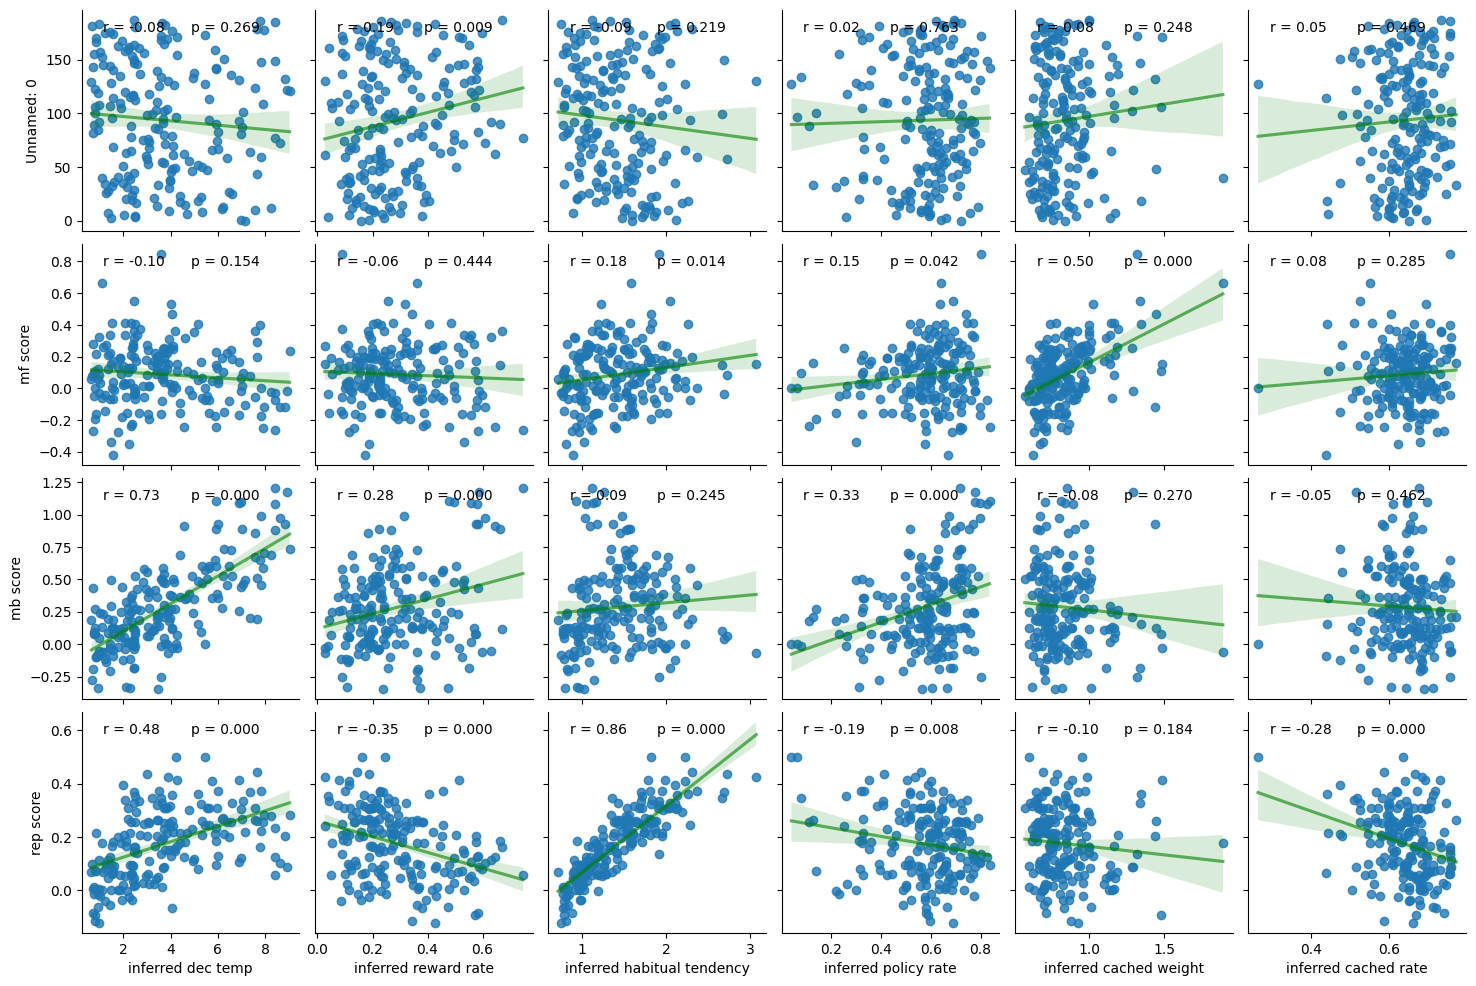

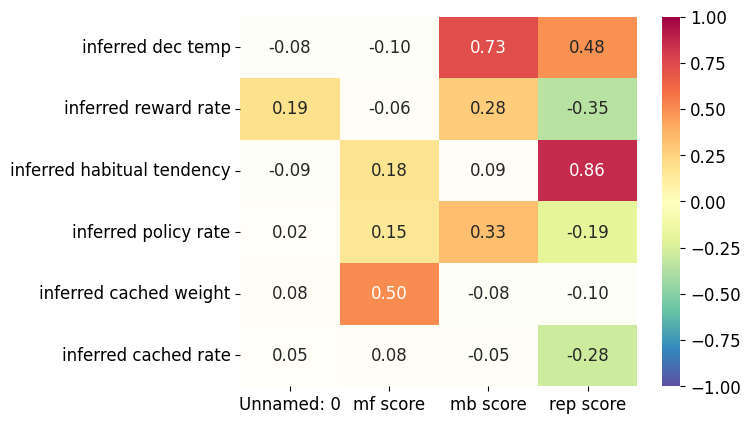

In [19]:
statistics_folder = os.path.join(results_folder, "statistics")

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

scores_df = pd.read_csv(scores_file)

mean_scores_df = pd.concat([mean_df, scores_df], axis='columns')#, join="inner")

plt.figure()
x_vars_of_interest = ["inferred "+name for name in param_names]
print(x_vars_of_interest)
y_vars_of_interest = list(scores_df.keys())
f = sns.pairplot(data=mean_scores_df, kind='reg', #diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=x_vars_of_interest, y_vars=y_vars_of_interest)
f.map(tu.annot_corrfunc)
#for p, p_range in enumerate(param_plot_ranges):
#    f.axes[2,p].set_xlim(p_range)
#    f.axes[p,0].set_ylim(p_range)
#plt.title("BCC3 analysis 1 correlations with scores")
plt.show()

iu.plot_correlations(mean_scores_df, x_vars_of_interest, y_vars_of_interest)